In [1]:
import rasterio
import rasterio.plot
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
%pwd

'/media/razydave/01DA189A333B1070/MendeFolder/08_BelceeriinDoroitol/Testing'

In [5]:
raster_path_drone = '../Drone_Orthomosaics/Orthos2024_10/3_Medium_2024_10_02/P4_MS/Medium_2024_10_P4_MS.tif'
src_drone = rasterio.open(raster_path_drone)
print(src_drone)

<open DatasetReader name='../Drone_Orthomosaics/Orthos2024_10/3_Medium_2024_10_02/P4_MS/Medium_2024_10_P4_MS.tif' mode='r'>


In [2]:
raster_path = "https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif"
src = rasterio.open(raster_path)
print(src)

<open DatasetReader name='https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif' mode='r'>


In [3]:
# Read the raster data into a NumPy array
raster_data = src.read(1)

# Find unique values in the array
unique_values = np.unique(raster_data)

print(unique_values)

[  15   16   18 ... 4321 4325 4338]


In [6]:
src.name

NameError: name 'src' is not defined

In [10]:
src.mode

'r'

In [11]:
src.meta

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': None,
 'width': 4269,
 'height': 3113,
 'count': 1,
 'crs': CRS.from_epsg(3857),
 'transform': Affine(90.0, 0.0, -13442488.3428,
        0.0, -89.99579177642138, 4668371.5775)}

In [8]:
src_drone.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': None,
 'width': 10991,
 'height': 11981,
 'count': 6,
 'crs': CRS.from_epsg(32648),
 'transform': Affine(0.024999110323364496, 0.0, 562797.4546599442,
        0.0, -0.024999565104181665, 5265253.578481229)}

In [7]:
src_drone.res

(0.024999110323364496, 0.024999565104181665)

`src.width` == how many columns
`src.height` == how many rows

In [16]:
src.width, src.height

(4269, 3113)

Number looks huge because of epsg 3857

In [9]:
src_drone.width

10991

In [10]:
src_drone.transform

Affine(0.024999110323364496, 0.0, 562797.4546599442,
       0.0, -0.024999565104181665, 5265253.578481229)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


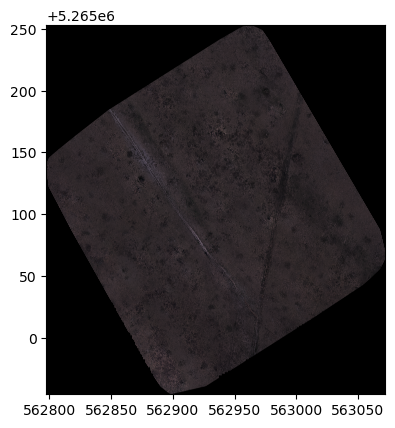

<Axes: >

In [11]:
rasterio.plot.show(src_drone,1)

In [26]:
src_drone.dtypes

('float32', 'float32', 'float32', 'float32', 'float32', 'float32')

Example vector

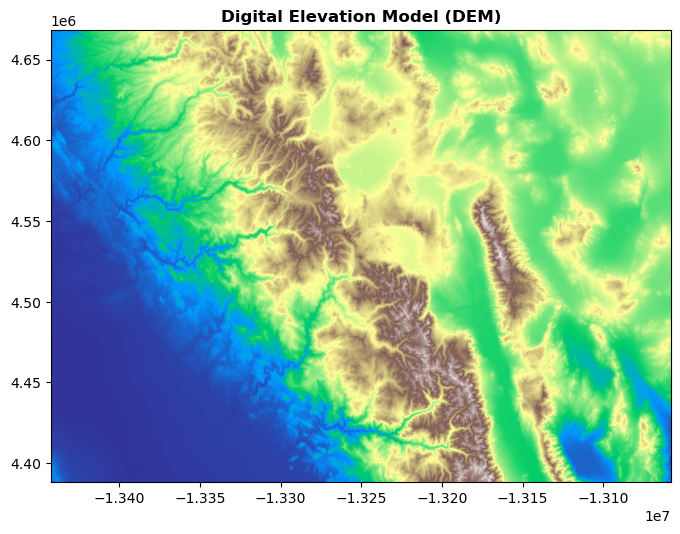

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))
rasterio.plot.show(src, cmap="terrain", ax=ax, title="Digital Elevation Model (DEM)")
plt.show()

In [29]:
dem_bounds = (
    "https://github.com/opengeos/datasets/releases/download/places/dem_bounds.geojson"
)
gdf = gpd.read_file(dem_bounds)
gdf = gdf.to_crs(src.crs)

<Axes: title={'center': 'Digital Elevation Model (DEM)'}>

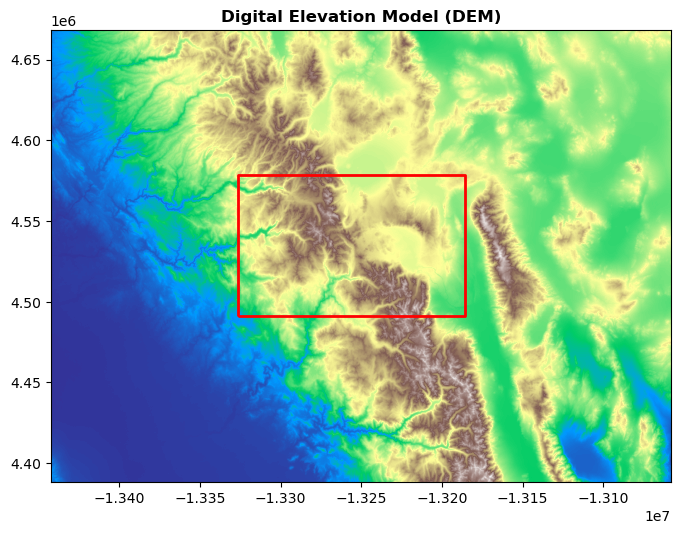

In [30]:
fig, ax = plt.subplots(figsize=(8, 8))
rasterio.plot.show(src, cmap="terrain", ax=ax, title="Digital Elevation Model (DEM)")
gdf.plot(ax=ax, edgecolor="red", facecolor="none", lw=2)

### Basic Band Math

In [12]:
nir_band = src_drone.read(4)
red_band = src_drone.read(1)

/tmp/ipykernel_105489/1536128451.py:1: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir_band - red_band) / (nir_band + red_band)


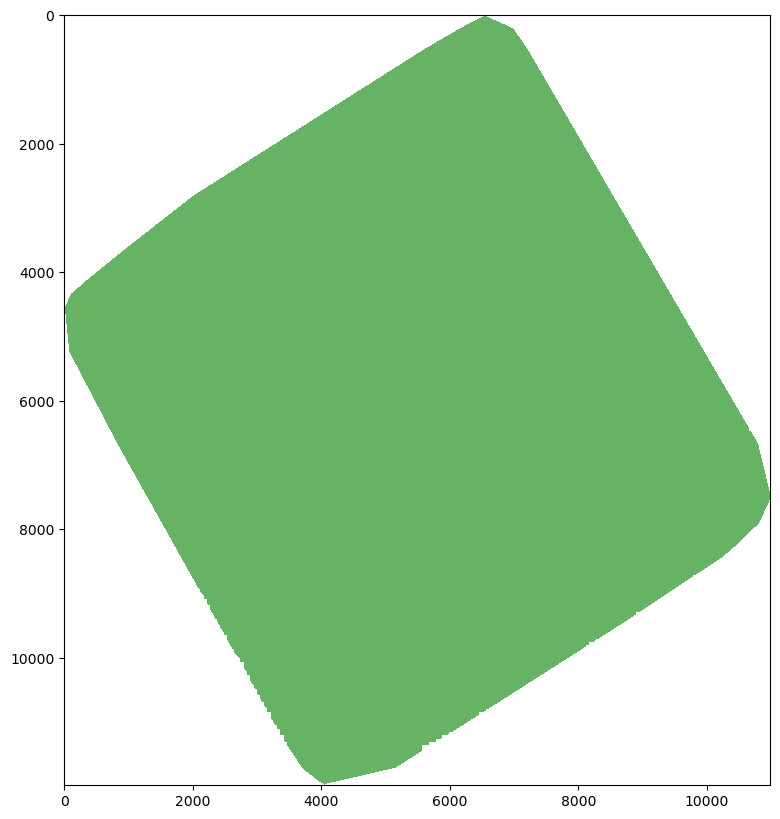

In [14]:
ndvi = (nir_band - red_band) / (nir_band + red_band)
# ndvi.clip(0, 1)

plt.figure(figsize=(10, 10))
plt.imshow(ndvi, cmap="summer")

### Objective: Find slices of misbehaving patches and investigate them separatly